# Những thư viện sử dụng cho việc Tiền xử lí dữ liệu dạng ảnh số:

- Chạy đoạn code bên dưới nếu chưa tải những thư viện cần thiết

In [1]:
%pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


- Khai báo những thư viện cần thiết

In [51]:
import os
import cv2                    
import numpy as np              
import pandas as pd         
import matplotlib.pyplot as plt
import seaborn as sns           
from glob import glob
import shutil
import kagglehub
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## I.Downloading the dataset:

Trong bước này, chúng ta tải bộ dữ liệu dạng bảng đã chọn trực tiếp từ Kaggle bằng thư viện **Kaggle** bằng thư viện `kagglehub`. Cách tiếp cận này giúp đảm bảo bộ dữ liệu luôn được lấy ở **phiên bản mới nhất hiện có**, từ đó nâng cao tính tái lập (reproducibility) và tính nhất quán giữa các môi trường khác nhau.

Sau khi tải xuống, toàn bộ các tệp dữ liệu sẽ được sao chép vào cấu trúc thư mục dự án đã được xác định trước (`data/images/`). Việc tổ chức này giúp duy trì bố cục gọn gàng, chuẩn hóa cho các thí nghiệm tiền xử lý dữ liệu.

In [ ]:
# Tải dữ liệu từ Kaggle và chuẩn bị thư mục
# 1. Tải dữ liệu từ Kaggle
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

# 2. Thiết lập thư mục đích
destination = "../data/images"

# Nếu thư mục đích đã tồn tại thì xóa
if os.path.exists(destination):
    shutil.rmtree(destination)

# 3. Copy toàn bộ dữ liệu sang thư mục đích
shutil.copytree(path, destination)
print(f"Path to dataset files have been copied to: {destination}")

# 4. Dọn dẹp thư mục đích
macosx_path = os.path.join(destination, "chest_xray/__MACOSX")
if os.path.exists(macosx_path):
    shutil.rmtree(macosx_path)
    print("Deleted __MACOSX")

# 5. Xoá các file .DS_Store
for root, dirs, files in os.walk(destination):
    for file in files:
        if file == ".DS_Store":
            os.remove(os.path.join(root, file))

# 6. Làm phẳng cấu trúc thư mục nếu cần thiết
nested_path = os.path.join(destination, "chest_xray")
if os.path.isdir(nested_path):
    print("Flattening folder chest_xray ...")

    for item in os.listdir(nested_path):
        src = os.path.join(nested_path, item)
        dst = os.path.join(destination, item)

        if not os.path.exists(dst):
            shutil.move(src, dst)
        else:
            print(f"Skipping {item} (already exists)")
    shutil.rmtree(nested_path)
    print("Deleted nested chest_xray folder")

print("\nDirectory structure after cleaning:")
for item in os.listdir(destination):
    print(f" - {item}")


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Path to dataset files have been copied to: ../data/images
Deleted __MACOSX
Flattening folder chest_xray ...
Skipping chest_xray (already exists)
Deleted nested chest_xray folder

Directory structure after cleaning:
 - test
 - train
 - val



AfSau khi tải xuống và tổ chức bộ dữ liệu, tệp sau đây có sẵn trong thư mục `data/tabular/`:

```
images/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
│
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
│
└── test/
    ├── NORMAL/
    └── PNEUMONIA/

```

Thư mục này chứa **Chest X-Ray Images (Pneumonia)**, được sử dụng cho phân tích khám phá dữ liệu (EDA), tiền xử lý và xây dựng các mô hình phân loại nhằm phát hiện viêm phổi.

  * Ảnh X-quang ngực (tư thế trước–sau) được lựa chọn từ các nhóm dữ liệu hồi cứu của bệnh nhi từ 1 đến 5 tuổi tại Bệnh viện Phụ sản & Nhi Quảng Châu (Guangzhou Women and Children’s Medical Center), Quảng Châu. Tất cả các ảnh X-quang ngực đều được chụp trong quá trình chăm sóc lâm sàng thường quy của bệnh nhân.

Bộ dữ liệu bao gồm các loại đặc trưng sau:

* **Chest X-Ray Images (Pneumonia)** được tổ chức thành 3 thư mục (train, test, val) và chứa các thư mục con cho từng loại ảnh (Pneumonia/Normal). Tổng cộng có 5.863 ảnh X-quang (định dạng JPEG) và 2 nhãn phân loại (Pneumonia/Normal).

**Nguồn dữ liệu:** Kaggle – [*Chest X-Ray Images (Pneumonia)*](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

**<span style="color:red">Lưu ý:</span>** **Trong bước tiền xử lý này, nhóm chúng tôi sử dụng bộ dữ liệu Chest X-Ray Images (Pneumonia) để huấn luyện. Bộ dữ liệu này chứa hơn 5.000 ảnh, một quy mô đủ lớn để đảm bảo hiệu quả về mặt tài nguyên.**

## II. Phân tích một số thông tin cơ bản của tập dữ liệu.

In [53]:
records = []

for label in os.listdir("../data/images/train"):
    label_path = os.path.join("../data/images/train", label)
    for filename in os.listdir(label_path):
        if filename.endswith(".jpeg"):
            img_path = os.path.join(label_path, filename)
            img = cv2.imread(img_path)
            h, w, _ = img.shape
            records.append({
                "label": label,
                "height": h,
                "width": w
            })

df_sizes = pd.DataFrame(records)
df_sizes.describe()

,height,width
count,5216.000000,5216.000000
mean,968.074770,1320.610813
std,378.855691,355.298743
min,127.000000,384.000000
25%,688.000000,1056.000000
50%,888.000000,1284.000000
75%,1187.750000,1552.000000
max,2663.000000,2916.000000


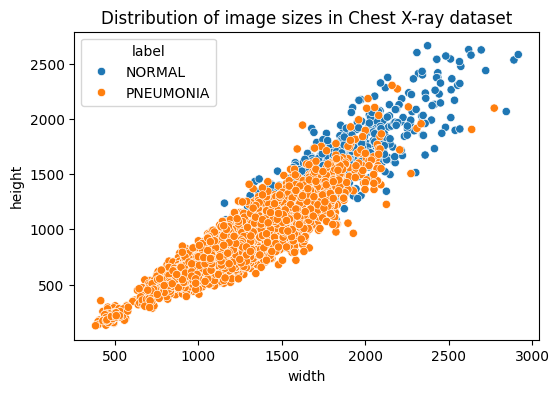

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_sizes, x="width", y="height", hue="label")
plt.title("Distribution of image sizes in Chest X-ray dataset")
plt.show()

In [10]:
path = "../data/images/train/NORMAL/NORMAL2-IM-0383-0001.jpeg"
def find_number_of_channels(path):
    img = cv2.imread(path)
    channels = img.shape[2] if len(img.shape) == 3 else 1
    print(f"Number of channels: {channels}")

find_number_of_channels(path)

Number of channels: 3


#### Nhận xét:
- Hình ảnh có kích thước phân bổ rất rộng từ nhỏ đến lớn rất đa dạng.
- Hình ảnh có số kênh màu là 3 (RGB)

### II. Loading and Resizing:

- Hàm hỗ trợ chọn 4 hình ảnh để trực quan kết quả.

In [12]:
def get_case_by_size(h, w):
    if w > 224 and h < 224:
        return "case1"
    elif 224 < w < 1500 and 224 < h < 1500:
        return "case2"
    elif 1500 < w < 2500 and 1500 < h < 2500:
        return "case3"
    elif w > 2500 and h > 2500:
        return "case4"
    return None

- Thay đổi kích thước ảnh thành 224x224 pixel (kích thước phổ biến cho các mô hình).

In [ ]:
def batch_resize_full_dataset(
    base_path,
    target_size=(224, 224),
    out_root="../output"
):
    resize_dir = os.path.join(out_root, "resized")

    os.makedirs(resize_dir, exist_ok=True)
    
    example_cases = {
        "case1": None,
        "case2": None,
        "case3": None,
        "case4": None
    }

    image_paths = glob(os.path.join(base_path, "*", "*.jpeg"))
    print(f"Total images to process: {len(image_paths)}")

    for idx, img_path in enumerate(image_paths, 1):
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape
        case = get_case_by_size(h, w)

        resized = cv2.resize(img, target_size)

        base_name = os.path.basename(img_path)

        cv2.imwrite(os.path.join(resize_dir, base_name), resized)

        if case and example_cases[case] is None:
            example_cases[case] = {
                "path": img_path,
                "original_size": (h, w),
                "filename": base_name
            }

        if idx % 500 == 0:
            print(f"Resized {idx}/{len(image_paths)} images")
        if idx == len(image_paths):
            print(f"Resized {idx}/{len(image_paths)} images")

    return example_cases


In [23]:
example_cases = batch_resize_full_dataset(
    base_path="../data/images/train"
)

Total images to process: 5216
Resized 500/5216 images
Resized 1000/5216 images
Resized 1500/5216 images
Resized 2000/5216 images
Resized 2500/5216 images
Resized 3000/5216 images
Resized 3500/5216 images
Resized 4000/5216 images
Resized 4500/5216 images
Resized 5000/5216 images
Resized 5216/5216 images


- Trực quan 4 ảnh được chọn ở trên sau khi thực hiện resize

Compare original vs resized sizes for example cases:


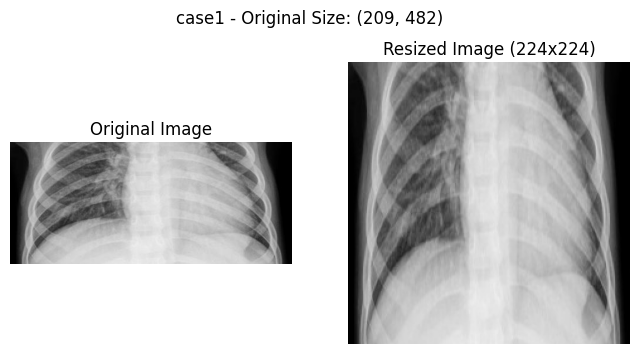

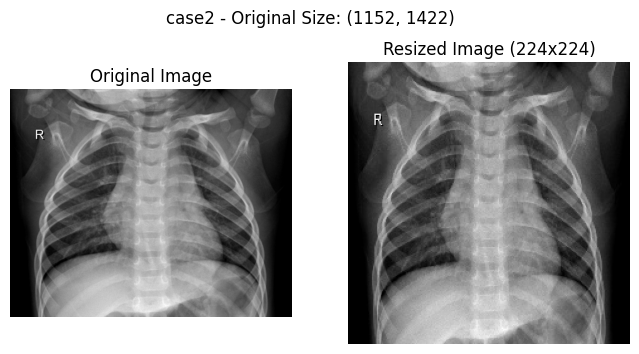

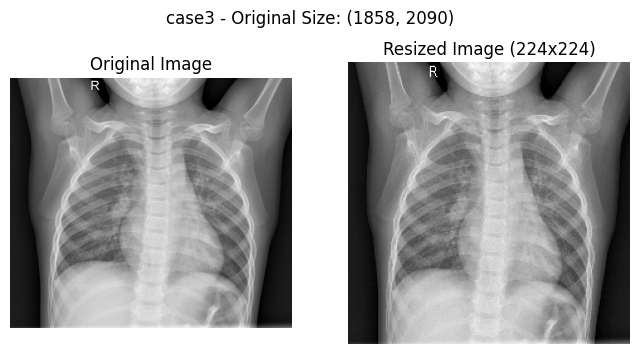

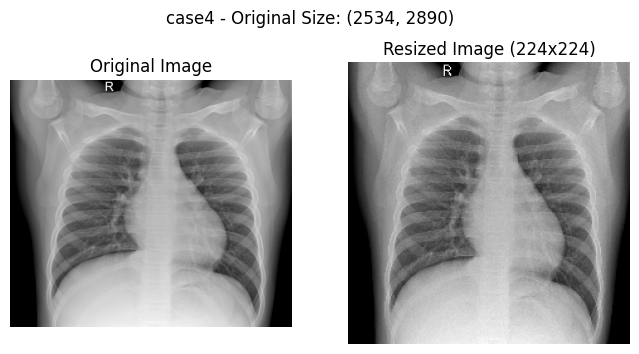

In [24]:
print("Compare original vs resized sizes for example cases:")
for case, info in example_cases.items():
    if info is None:
        continue

    img_path = info["path"]
    original_size = info["original_size"]
    filename = info["filename"]

    original_img = cv2.imread(img_path)
    resized_img = cv2.imread(os.path.join("../output/resized", filename))

    plt.figure(figsize=(8, 4))
    plt.suptitle(f"{case} - Original Size: {original_size}")

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Resized Image (224x224)")
    plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

- So sánh kích thước thư mục ảnh trước và sau khi resize

In [25]:
def get_folder_size(folder_path):
    total_size = 0
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            fp = os.path.join(root, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return total_size  # bytes

def bytes_to_mb(bytes_size):
    return bytes_size / (1024 * 1024)

original_size = get_folder_size("../data/images/train")
resized_size = get_folder_size("../output/resized")

print(f"Original dataset size: {bytes_to_mb(original_size):.2f} MB")
print(f"Resized dataset size: {bytes_to_mb(resized_size):.2f} MB")

Original dataset size: 1100.92 MB
Resized dataset size: 91.47 MB


#### Nhận xét kết quả trước và sau khi thay đổi kích thước:
- Việc lựa chọn kích thước (224x224) đến từ những lý do sau:
  - Ở độ phân giải 224×224, nhiều mạng có thể sử dụng kích thước batch thực tế trên bộ nhớ GPU thông thường, điều này giúp tăng tốc độ hội tụ và ổn định thống kê chuẩn batch.
  - sự phổ biến rộng rãi của các mô hình được huấn luyện trước ở độ phân giải 224×224 như các kiến trúc CNN hiện đại (VGG, ResNet, DenseNet)
  - Việc thay đổi sẽ giúp làm giảm tài nguyên lưu trữ và giảm áp lực lên những thiết bị phần cứng.
- Sự đánh đổi giữa kích thước ảnh và hiệu quả tính toán:
  - Độ phân giải 224×224 đủ nhỏ để cho phép huấn luyện/suy luận tương đối nhanh trên GPU, nhưng cũng đủ lớn để giữ lại các đặc điểm nổi bật của đối tượng cho việc phân loại. Kích thước lớn hơn sẽ làm tăng số phép tính FLOPs và bộ nhớ theo tỷ lệ bình phương.
  - Đối với ngữ cảnh ảnh x-quang về phổi nhìn chung những chi tiết chính đều được giữ lại nhưng từ một ảnh có kích thước rất lớn thì khả năng giữ lại những chi tiết nhỏ thấp
  - Việc thay đổi kích thước cũng sẽ làm một số ảnh dọc và ngang sẽ bị kéo chiều thành hình vuông vì vậy một số ảnh sẽ bị méo hơn so với ảnh gốc ban đầu.

### III. Grayscale Conversion:

- Chuyển đổi ảnh đã thay đổi kích thước từ định dạng RGB sang ảnh xám.

In [35]:
def batch_grayscale_full_dataset(
    base_path,
    out_root="../output"
):
    resize_dir = os.path.join(out_root, "grayscale")
    os.makedirs(resize_dir, exist_ok=True)

    image_paths = glob(os.path.join(base_path, "*.jpeg"))
    print(f"Total images to process: {len(image_paths)}")

    for idx, img_path in enumerate(image_paths, 1):
        img = cv2.imread(img_path)
        if img is None:
            continue

        grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        base_name = os.path.basename(img_path)

        cv2.imwrite(os.path.join(resize_dir, base_name), grayscale)

        if idx % 500 == 0:
            print(f"Resized {idx}/{len(image_paths)} images")
        if idx == len(image_paths):
            print(f"Resized {idx}/{len(image_paths)} images")

In [36]:
batch_grayscale_full_dataset(
    base_path="../output/resized"
)

Total images to process: 5216
Resized 500/5216 images
Resized 1000/5216 images
Resized 1500/5216 images
Resized 2000/5216 images
Resized 2500/5216 images
Resized 3000/5216 images
Resized 3500/5216 images
Resized 4000/5216 images
Resized 4500/5216 images
Resized 5000/5216 images
Resized 5216/5216 images


- Trực quan 4 ảnh sau ở trên sau khi chuyển đổi sang ảnh xám

Compare resized vs grayscale for example cases:


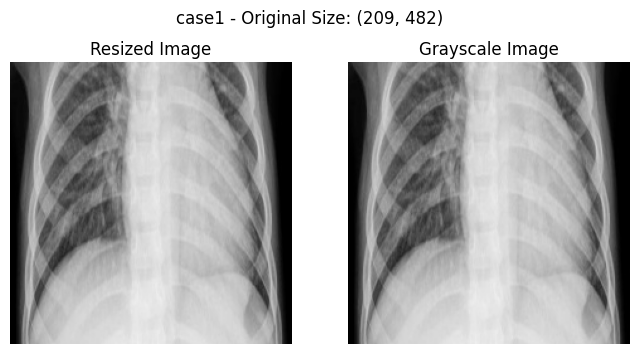

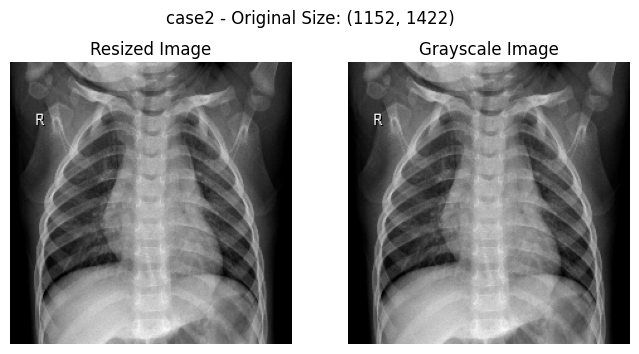

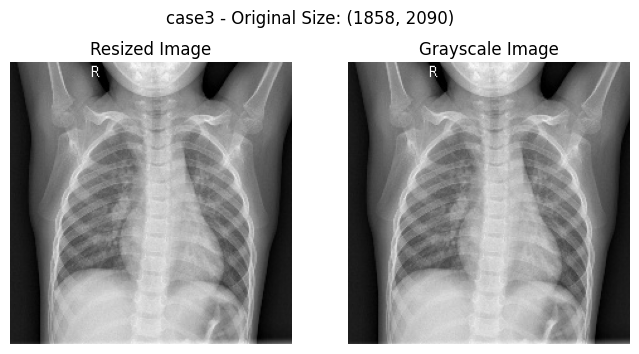

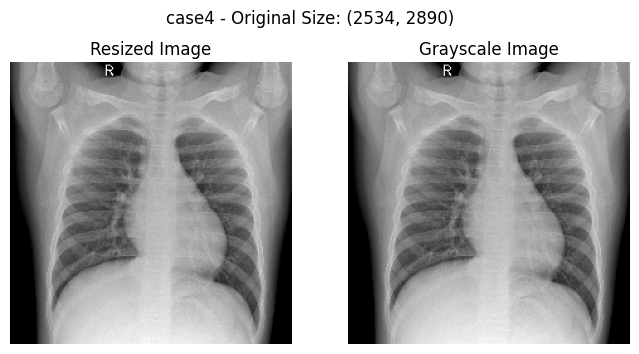

In [37]:
print("Compare resized vs grayscale for example cases:")
for case, info in example_cases.items():
    if info is None:
        continue

    img_path = info["path"]
    original_size = info["original_size"]
    filename = info["filename"]

    resized_img = cv2.imread(os.path.join("../output/resized", filename))
    grayscale_img = cv2.imread(os.path.join("../output/grayscale", filename))

    plt.figure(figsize=(8, 4))
    plt.suptitle(f"{case} - Original Size: {original_size}")

    plt.subplot(1, 2, 1)
    plt.title("Resized Image")
    plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grayscale Image")
    plt.imshow(cv2.cvtColor(grayscale_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

- So sánh kích thước thư mục chứa ảnh trước và sau khi chuyển màu

In [38]:
resized_size = get_folder_size("../output/resized")
grayscale_size = get_folder_size("../output/grayscale")

print(f"Resized dataset size: {bytes_to_mb(resized_size):.2f} MB")
print(f"Grayscale dataset size: {bytes_to_mb(grayscale_size):.2f} MB")

Resized dataset size: 91.47 MB
Grayscale dataset size: 89.03 MB


#### Nhận xét kết quả trước và sau khi thay đổi kênh màu:
- Đối với ngữ cảnh ảnh X-ray thì việc thay đổi kênh màu từ RGB sang Grayscale thì hình ảnh gần như không có gì thay đổi vì ảnh gốc có màu tương tự như grayscale.
- Việc thay đổi kênh màu sẽ giúp cho giảm nhẹ kích thước lưu trữ hình.
- Điểm lợi lớn nhất là việc tính toán trên kênh màu grayscale sẽ nhanh hơn nhiều so với kênh màu RGB
- Với việc chuyển đổi grayscale trên ngữ cảnh ảnh x-ray như thế này gần như không có điểm hại.

### IV. Normalization:

- In this step, we perform normalization using two strategies, min-max and z-score, on the four images selected in the previous steps.

Histogram of pixel intensities for normalization:


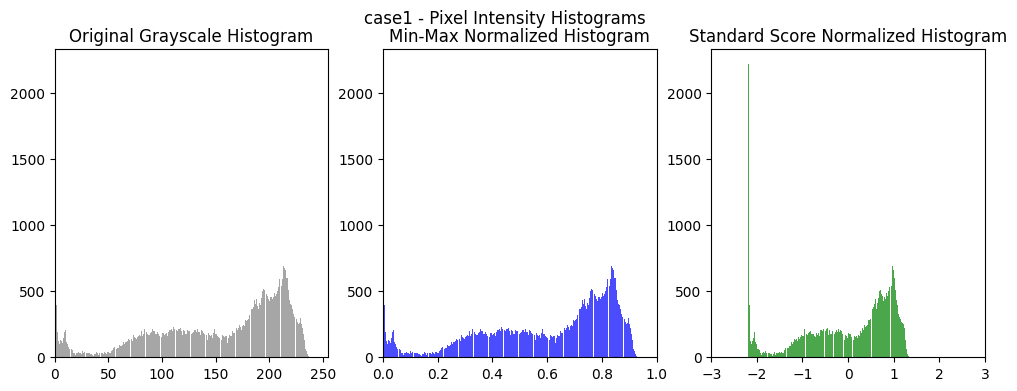

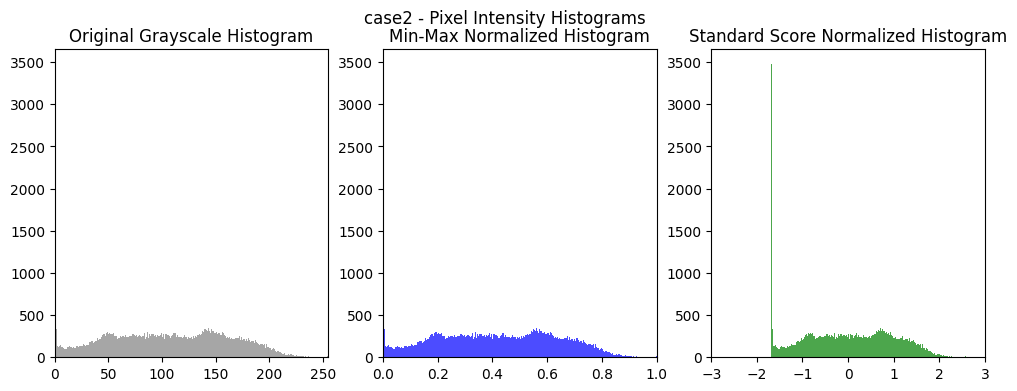

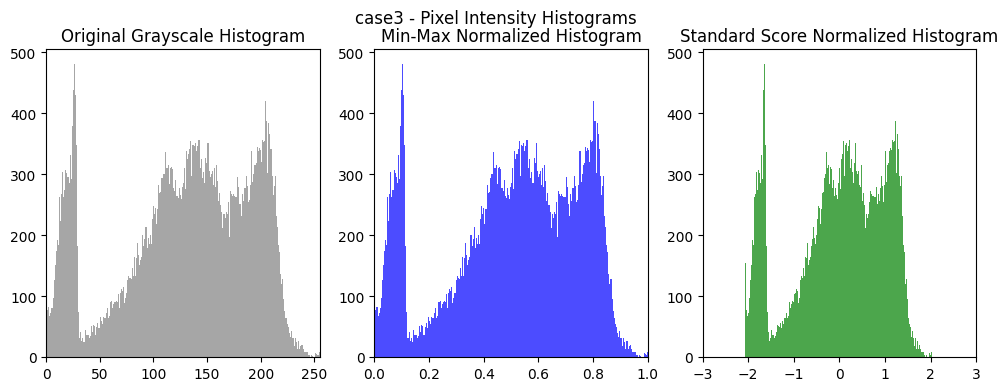

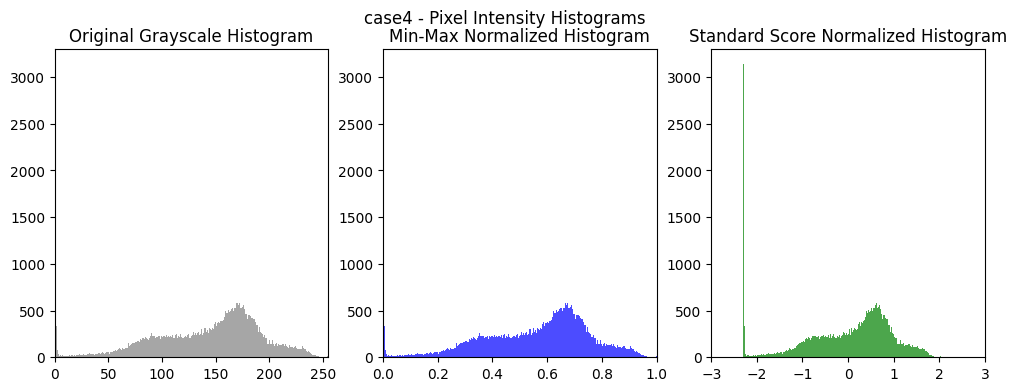

In [41]:
print("Histogram of pixel intensities for normalization:")

for case, info in example_cases.items():
    if info is None:
        continue

    filename = info["filename"]
    gray_img = cv2.imread(os.path.join("../output/grayscale", filename), cv2.IMREAD_GRAYSCALE)

    minmax = gray_img.astype(np.float32) / 255.0

    mean, std = np.mean(gray_img), np.std(gray_img)
    standard = (gray_img - mean) / std

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"{case} - Pixel Intensity Histograms")

    plt.subplot(1, 3, 1)
    plt.title("Original Grayscale Histogram")
    plt.hist(gray_img.ravel(), bins=256, color='gray', alpha=0.7)
    plt.xlim([0, 255])

    plt.subplot(1, 3, 2)
    plt.title("Min-Max Normalized Histogram")
    plt.hist(minmax.ravel(), bins=256, color='blue', alpha=0.7)
    plt.xlim([0, 1])

    plt.subplot(1, 3, 3)
    plt.title("Standard Score Normalized Histogram")
    plt.hist(standard.ravel(), bins=256, color='green', alpha=0.7)
    plt.xlim([-3, 3])

    plt.show()

#### Nhận xét kết quả trước và sau khi chuẩn hóa:
- Đối với chuẩn hóa Min-Max chỉ thực hiện phép co giãn tuyến tính và giữ nguyên hình dạng phân bố dữ liệu. Việc này có thể giúp cải thiện khả năng xử lý
- Đối với chuẩn hóa Z-Score có sự thay đổi nhẹ về hình dạng phân bố dữ liệu nhưng việc này sẽ phù hợp cho các mô hình học máy.

### V. Edge Detection:

- Ở bước này, chúng tôi sử dụng 3 chiến lược edge detection: Canny, Prewitt, and Sobel.

In [47]:
def batch_edge_detection_full_dataset(
    base_path,
    out_root="../output"
):
    canny_dir = os.path.join(out_root, "canny_edges")
    prewitt_dir = os.path.join(out_root, "prewitt_edges")
    sobel_dir = os.path.join(out_root, "sobel_edges")

    for d in [canny_dir, prewitt_dir, sobel_dir]:
        os.makedirs(d, exist_ok=True)

    image_paths = glob(os.path.join(base_path, "*.jpeg"))
    print(f"Total images to process: {len(image_paths)}")

    for idx, img_path in enumerate(image_paths, 1):
        img = cv2.imread(img_path)
        if img is None:
            continue

        edges_canny = cv2.Canny(img, 100, 200)

        kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
        kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
        edges_prewitt_x = cv2.filter2D(img, -1, kernelx)
        edges_prewitt_y = cv2.filter2D(img, -1, kernely)
        edges_prewitt = cv2.addWeighted(np.abs(edges_prewitt_x), 0.5, np.abs(edges_prewitt_y), 0.5, 0)

        edges_sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
        edges_sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
        edges_sobel = cv2.magnitude(edges_sobel_x, edges_sobel_y)
        edges_sobel_norm = cv2.normalize(
            edges_sobel,
            None,
            0, 255,
            cv2.NORM_MINMAX
        )
        edges_sobel = edges_sobel_norm.astype(np.uint8)

        base_name = os.path.basename(img_path)

        cv2.imwrite(os.path.join(canny_dir, base_name), edges_canny)
        cv2.imwrite(os.path.join(prewitt_dir, base_name), edges_prewitt)
        cv2.imwrite(os.path.join(sobel_dir, base_name), edges_sobel)

        if idx % 500 == 0:
            print(f"Resized {idx}/{len(image_paths)} images")
        if idx == len(image_paths):
            print(f"Resized {idx}/{len(image_paths)} images")

In [48]:
batch_edge_detection_full_dataset(
    base_path="../output/grayscale"
)

Total images to process: 5216
Resized 500/5216 images
Resized 1000/5216 images
Resized 1500/5216 images
Resized 2000/5216 images
Resized 2500/5216 images
Resized 3000/5216 images
Resized 3500/5216 images
Resized 4000/5216 images
Resized 4500/5216 images
Resized 5000/5216 images
Resized 5216/5216 images


- So sánh ảnh trước và sau khi áp dụng thuật toán edge detection.

Print edge detection results for different cases:


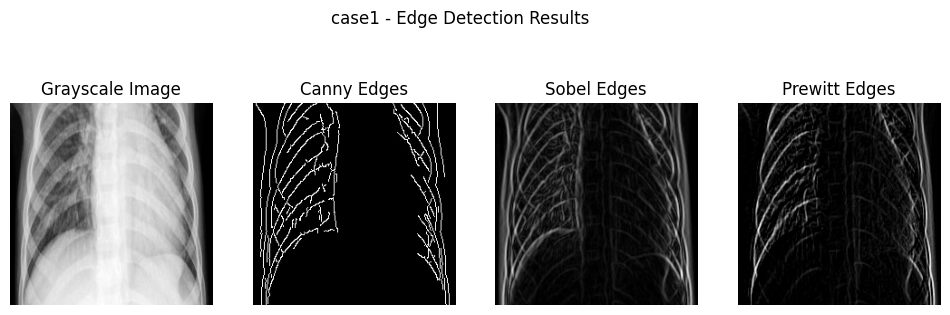

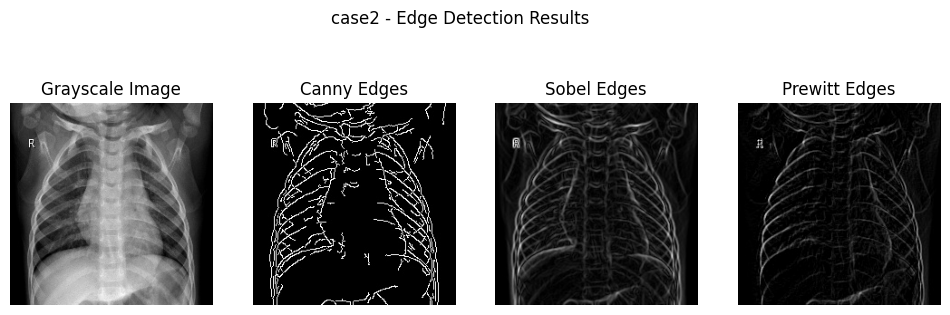

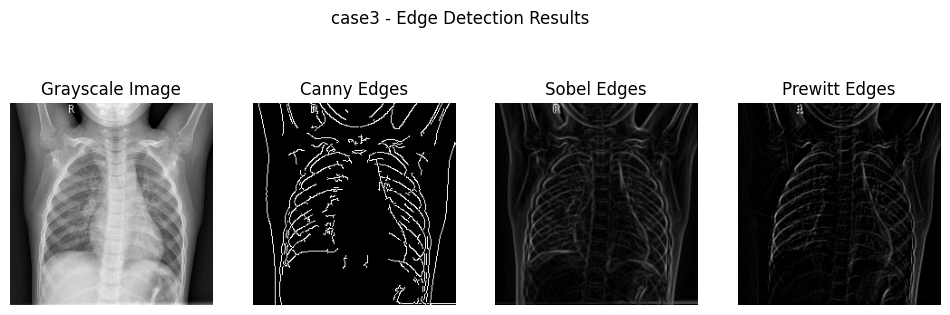

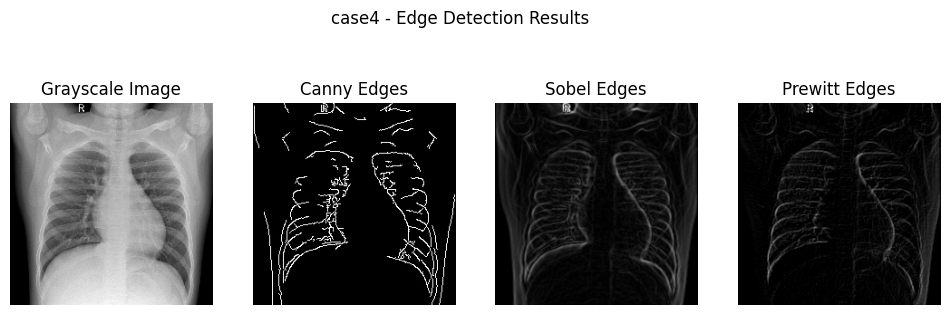

In [50]:
print("Print edge detection results for different cases:")
for case, info in example_cases.items():
    if info is None:
        continue

    filename = info["filename"]

    gray_img = cv2.imread(os.path.join("../output/grayscale", filename), cv2.IMREAD_GRAYSCALE)
    edges_canny = cv2.imread(os.path.join("../output/canny_edges", filename), cv2.IMREAD_GRAYSCALE)
    edges_sobel = cv2.imread(os.path.join("../output/sobel_edges", filename), cv2.IMREAD_GRAYSCALE)
    edges_prewitt = cv2.imread(os.path.join("../output/prewitt_edges", filename), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"{case} - Edge Detection Results")

    plt.subplot(1, 4, 1)
    plt.title("Grayscale Image")
    plt.imshow(gray_img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("Canny Edges")
    plt.imshow(edges_canny, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("Sobel Edges")
    plt.imshow(edges_sobel, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Prewitt Edges")
    plt.imshow(edges_prewitt, cmap='gray')
    plt.axis('off')

    plt.show()

#### Nhận xét kết quả trước và sau khi áp dụng edge detection:
- Đối với thuật toán canny edges: Hình ảnh sau khi sử dụng thuật toán chỉ có những đường nét rất mảnh và khác xa rất nhiều so vớ ảnh gốc điều này khiến cho độ hiệu quả sẽ không cao.
- Đối với thuật toán Prewitt và Sobel: Hai thuật toán này cho ra kết quả tương đối giống nhau nhưng Sobel sẽ có sự nhỉnh hơn về hình ảnh khi các đường nét được thể hiện rõ ràng hơn và chi tiết hơn.
- **Nhìn chung**: Với bối cảnh bài toán phát hiện viêm phổi của tập dataset thì việc sử dụng các thuật toán phát hiện cạnh sẽ không có sự giúp ích gì nhiều vì bệnh này chủ yếu được phát hiện bằng cách vùng màu trong phổi nên việc phát hiện cạnh gần như chỉ phát hiện được hình dáng của phổi và khung xương sườn.